In [1]:
import pandas as pd
import fsspec
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
#https://github.com/CSSEGISandData/COVID-19
import pandas as pd
import fsspec

# Configura el sistema de archivos de GitHub con fsspec sin token
github_fs = fsspec.filesystem('github', org='CSSEGISandData', repo='COVID-19', ref='master')

# Listar los archivos en la carpeta específica dentro del repositorio
files_name = github_fs.ls('csse_covid_19_data/csse_covid_19_daily_reports_us')

# Filtrar solo los primeros 20 archivos CSV
files_name = [file for file in files_name if file.endswith('.csv')][:20]

# Crear una lista para almacenar los DataFrames
dfs = []

# Iterar sobre los primeros 20 archivos listados
for file_name in files_name:
    # Abrir y leer el archivo CSV
    with github_fs.open(file_name, 'rb') as f:
        df = pd.read_csv(f)
        dfs.append(df)

# Concatenar todos los DataFrames en uno solo
data_frame = pd.concat(dfs, ignore_index=True)

# Mostrar las primeras filas del DataFrame resultante
print(data_frame.head())

   Province_State Country_Region          Last_Update      Lat     Long_  \
0         Alabama             US  2021-01-02 05:30:44  32.3182  -86.9023   
1          Alaska             US  2021-01-02 05:30:44  61.3707 -152.4044   
2  American Samoa             US  2021-01-02 05:30:44 -14.2710 -170.1320   
3         Arizona             US  2021-01-02 05:30:44  33.7298 -111.4312   
4        Arkansas             US  2021-01-02 05:30:44  34.9697  -92.3731   

   Confirmed  Deaths  Recovered    Active  FIPS  ...  Total_Test_Results  \
0     365747    4872   202137.0  158738.0   1.0  ...                 NaN   
1      47019     206     7165.0   39648.0   2.0  ...           1275750.0   
2          0       0        NaN       NaN  60.0  ...              2140.0   
3     530267    9015    76934.0  444318.0   4.0  ...           5155330.0   
4     229442    3711   199247.0   26484.0   5.0  ...           2051488.0   

   People_Hospitalized  Case_Fatality_Ratio         UID  ISO3   Testing_Rate  \
0     

In [3]:
print(data_frame.dtypes)

# Renombrando las 21 columnas (mapeo total)
data_frame = data_frame.rename(columns={
    'Province_State': 'estado',
    'Country_Region': 'pais',
    'Last_Update': 'ultima_actualizacion',
    'Lat': 'latitud',
    'Long_': 'longitud',
    'Confirmed': 'confirmados',
    'Deaths': 'muertes',
    'Recovered': 'recuperados',
    'Active': 'activos',
    'FIPS': 'fips',
    'Incident_Rate': 'tasa_incidencia',
    'Total_Test_Results': 'total_tests',
    'People_Hospitalized': 'perso_hospit',
    'Case_Fatality_Ratio': 'ratio_fatal',
    'UID': 'uid',
    'ISO3': 'iso3',
    'Testing_Rate': 'tasa_test',
    'Hospitalization_Rate': 'tasa_hospitalizacion',
    'Date': 'fecha',
    'People_Tested': 'personas_testeadas',
    'Mortality_Rate': 'tasa_mortal'
})

# Verificamos que sigan siendo 21 con nombres nuevos
print(f"\nTotal columnas: {len(data_frame.columns)}")
print(data_frame.dtypes)


Province_State           object
Country_Region           object
Last_Update              object
Lat                     float64
Long_                   float64
Confirmed                 int64
Deaths                    int64
Recovered               float64
Active                  float64
FIPS                    float64
Incident_Rate           float64
Total_Test_Results      float64
People_Hospitalized     float64
Case_Fatality_Ratio     float64
UID                     float64
ISO3                     object
Testing_Rate            float64
Hospitalization_Rate    float64
Date                     object
People_Tested           float64
Mortality_Rate          float64
dtype: object

Total columnas: 21
estado                   object
pais                     object
ultima_actualizacion     object
latitud                 float64
longitud                float64
confirmados               int64
muertes                   int64
recuperados             float64
activos                 float64
fips  

In [4]:
# seleccionar
provinEstado="estado"
ultAct="ultima_actualizacion"
confir="confirmados"
fallecidos="muertes"
recuperados="recuperados"

df_confirmados=data_frame[[provinEstado,ultAct,confir]]
df_fallecidos=data_frame[[provinEstado,ultAct,fallecidos]]
df_recuperados=data_frame[[provinEstado,ultAct,recuperados]]


In [5]:
# eliminar vacios
df_confirmados=df_confirmados.dropna(axis=0,how='any')
df_fallecidos=df_fallecidos.dropna(axis=0,how='any')
df_recuperados=df_recuperados.dropna(axis=0,how='any')

# confirmar si hay valore nulos
for dataF in [df_confirmados,df_fallecidos,df_recuperados]:
  print(dataF.isnull().sum(),"\n")


estado                  0
ultima_actualizacion    0
confirmados             0
dtype: int64 

estado                  0
ultima_actualizacion    0
muertes                 0
dtype: int64 

estado                  0
ultima_actualizacion    0
recuperados             0
dtype: int64 



In [6]:



## graficos
def realizar_grafica(df,column):

  df["ultima_actualizacion"]=pd.to_datetime(df["ultima_actualizacion"])

  df_ultimo_dia=df[(df["ultima_actualizacion"].dt.day == 12) & (df["ultima_actualizacion"].dt.month == 1).copy() ]
  # reset index cuando se repite el indice
  df_ultimo_dia['año'] = df_ultimo_dia["ultima_actualizacion"].dt.year

  casos_anio = df_ultimo_dia.groupby(["estado", "año"])[column].sum().reset_index()


  casos_anio=casos_anio.rename(columns={"ultima_actualizacion":"año"})

  max_casos=casos_anio[column].max()
  min_casos=casos_anio[column].min()

  sns.set(style='whitegrid')
  plt.figure(figsize=(12,6))
  sns.barplot(data=casos_anio,x='estado',y=column,hue='año')
  plt.title(f'Evolución de {column} por Estado')
  plt.xticks(rotation=45)

  plt.show()






In [7]:
def realizar_grafica(df, column):
    df["ultima_actualizacion"] = pd.to_datetime(df["ultima_actualizacion"])


    df_ultimo_dia = df[(df["ultima_actualizacion"].dt.day == 2) &
                       (df["ultima_actualizacion"].dt.month == 1)].copy()

    if df_ultimo_dia.empty:
        # Si sigue vacío, imprimimos qué fechas hay para saber qué buscar
        fechas_disponibles = df["ultima_actualizacion"].dt.strftime('%d/%m').unique()
        print(f"No hay datos para esa fecha. Fechas disponibles (día/mes): {fechas_disponibles}")
        return

    df_ultimo_dia['año'] = df_ultimo_dia["ultima_actualizacion"].dt.year
    casos_anio = df_ultimo_dia.groupby(["estado", "año"])[column].sum().reset_index()

    sns.set(style='whitegrid')
    plt.figure(figsize=(15, 7))

    # Agregué 'order' para que los estados salgan ordenados por cantidad
    estados_ordenados = casos_anio.groupby("estado")[column].sum().sort_values(ascending=False).index

    sns.barplot(data=casos_anio, x='estado', y=column, hue='año', order=estados_ordenados)

    plt.title(f'Evolución de {column.upper()} por Estado')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()


In [8]:
def realizar_grafica(df, column, dia=2, mes=1):
    # 1. Convertir a fecha
    df["ultima_actualizacion"] = pd.to_datetime(df["ultima_actualizacion"])

    # 2. Filtrar datos
    df_ultimo_dia = df[(df["ultima_actualizacion"].dt.day == dia) &
                       (df["ultima_actualizacion"].dt.month == mes)].copy()

    if df_ultimo_dia.empty:
        print(f"No hay datos para el {dia}/{mes}")
        return

    # 3. Crear columna año y agrupar
    df_ultimo_dia['año'] = df_ultimo_dia["ultima_actualizacion"].dt.year
    casos_anio = df_ultimo_dia.groupby(["estado", "año"])[column].sum().reset_index()

    # 4. Calcular mínimos y máximos
    max_casos = casos_anio[column].max()
    min_casos = casos_anio[column].min()

    # 5. Configurar gráfica
    sns.set(style='whitegrid')
    plt.figure(figsize=(12, 6))

    sns.barplot(data=casos_anio, x='estado', y=column, hue='año')

    # 6. Líneas de Máximo y Mínimo corregidas
    plt.axhline(y=max_casos, color="green", linestyle='--', label=f'Max: {max_casos:,.0f}')
    plt.axhline(y=min_casos, color="red", linestyle=':', label=f'Min: {min_casos:,.0f}')

    plt.title(f'Evolución de {column} por Estado')
    plt.xticks(rotation=90)
    plt.legend() # Importante para mostrar las etiquetas de las líneas
    plt.tight_layout()
    plt.show()


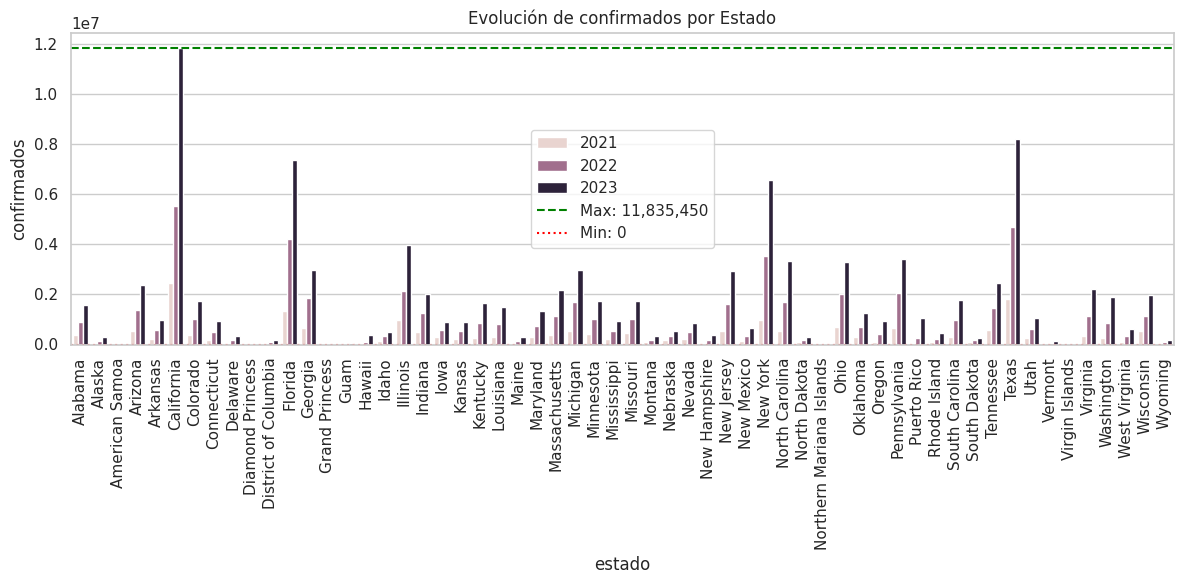

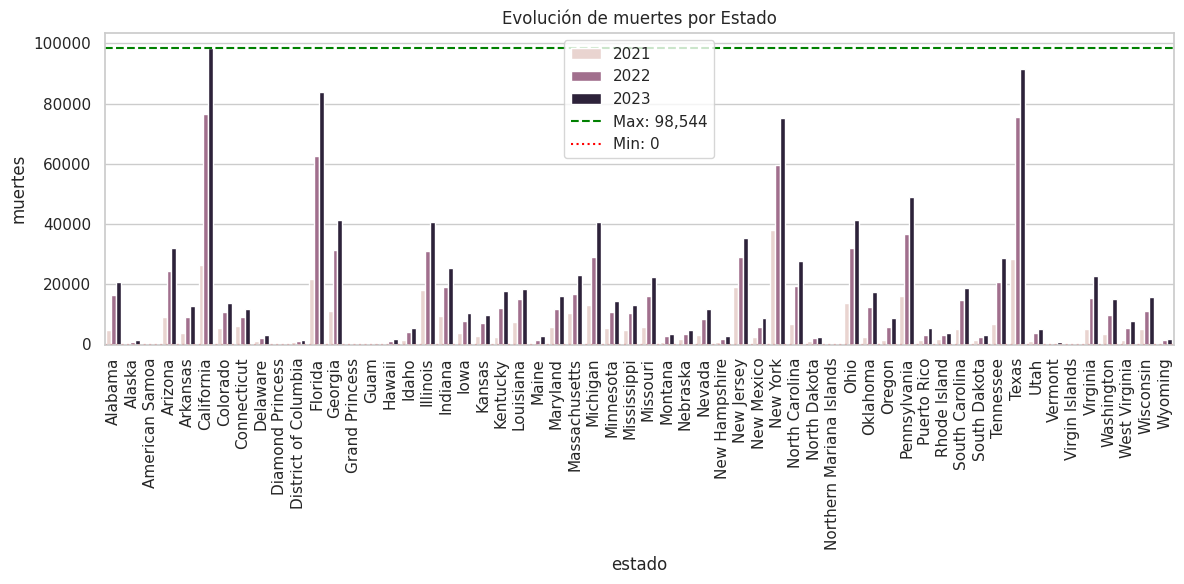

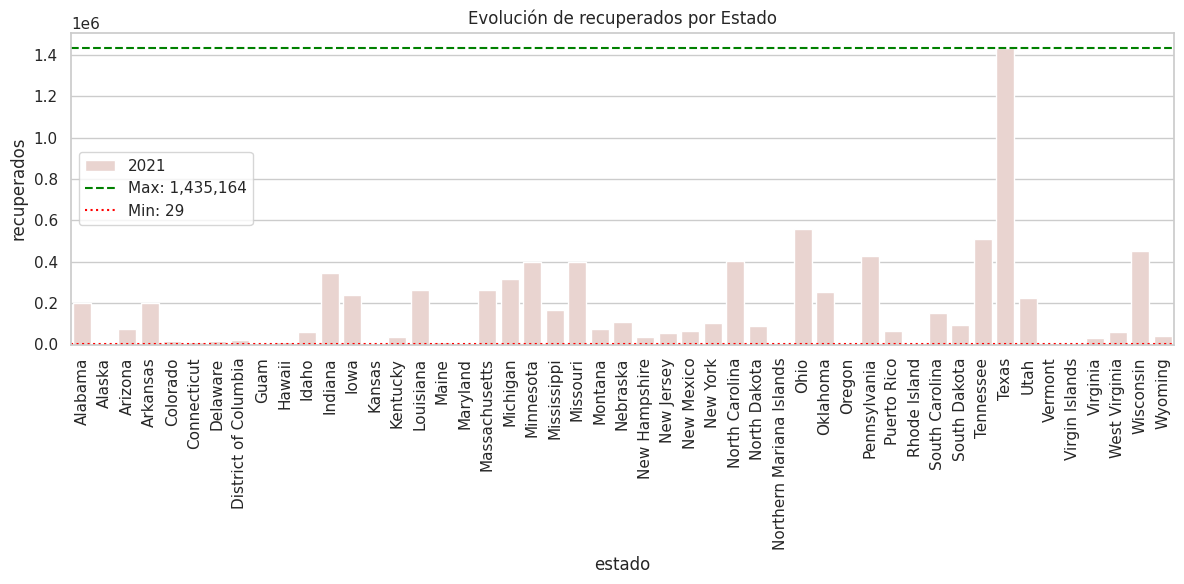

In [9]:
# Llamados
realizar_grafica(df_confirmados, "confirmados")
realizar_grafica(df_fallecidos, "muertes")
realizar_grafica(df_recuperados, "recuperados")